# Sprint 9 - Webinar 21: Análisis de Métricas y Recomendaciones de Marketing

Este notebook realiza un análisis utilizando tres datasets:

* **visits:** Registra las visitas al sitio web (con columnas *Uid*, *Device*, *Start Ts*, *End Ts*, *Source Id*).
* **orders:** Registra los pedidos realizados (con columnas *Uid*, *Buy Ts*, *Revenue*).
* **costs:** Registra los gastos en publicidad (con columnas *source_id*, *dt*, *costs*).

Además, se genera un dataset **sintético** (con la misma estructura y columnas) para ilustrar cómo se pueden analizar datos simulados.

El proyecto abarca los siguientes pasos:

1. **Exploración y preparación de los datos.**
2. **Cálculo de métricas e informes para visitas, ventas y marketing.**
   - Visitas: Usuarios únicos diarios, semanales y mensuales, sesiones diarias, duración de las sesiones y frecuencia de retorno.
   - Ventas: Tiempo hasta la conversión (de registro a la primera compra), cantidad de pedidos, tamaño promedio de compra y Lifetime Value (LTV).
   - Marketing: Gasto total (y por fuente), costo de adquisición de clientes (CAC) y rentabilidad de las inversiones (ROMI). Se incluyen gráficos segmentados por dispositivo y fuente de anuncios.
3. **Conclusiones y recomendaciones.**

Las celdas de código y de texto están organizadas y documentadas para facilitar la comprensión del análisis.

## 1. Importación de librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import datetime

## 2. Carga de Datos Reales

A continuación se cargan los datasets reales proporcionados. Se asume que los archivos están disponibles en las rutas indicadas. Se convierten las columnas de fecha a objetos datetime para facilitar su manejo.

## 3. Generación de Dataset Sintético

A continuación se genera un conjunto de datos sintéticos con la misma estructura que los datasets reales. Esto nos permitirá simular y validar el análisis sin depender únicamente de los datos proporcionados.

**Estructura de los datos sintéticos:**

* **visits_synth:**
  - *Uid:* identificador único del usuario.
  - *Device:* Dispositivo del usuario (ej. 'desktop', 'mobile', 'tablet').
  - *Start Ts:* Fecha y hora de inicio de la sesión.
  - *End Ts:* Fecha y hora de término de la sesión.
  - *Source Id:* Identificador de la fuente de anuncios.

* **orders_synth:**
  - *Uid:* Identificador único del usuario.
  - *Buy Ts:* Fecha y hora de la compra.
  - *Revenue:* Ingreso generado por la orden.

* **costs_synth:**
  - *source_id:* Identificador de la fuente de anuncios.
  - *dt:* Fecha.
  - *costs:* Gasto realizado en esa fuente en el día.


In [31]:
# Generar dataset sintético para 'visits'

np.random.seed(42)
n_visits = 500
uids = np.random.choice([f'U{i:03d}' for i in range(1, 101)], size=n_visits)
devices = np.random.choice(['desktop', 'mobile', 'tablet'], size=n_visits, p=[0.5, 0.4, 0.1])

# Generar fechas de inicio dentro de un período de 60 días
start_dates = pd.to_datetime('2025-01-01') + pd.to_timedelta(np.random.randint(0, 60, size=n_visits), unit='D')
start_times = start_dates + pd.to_timedelta(np.random.randint(0, 86400, size=n_visits), unit='s')

# Duración de sesión entre 5 y 60 minutos
durations = np.random.randint(5, 60, size=n_visits)
end_times = start_times + pd.to_timedelta(durations, unit='m')

source_ids = np.random.choice(['google', 'facebook', 'twitter', 'linkedin'], size=n_visits)

visits = pd.DataFrame({
    'Uid': uids,
    'Device': devices,
    'Start Ts': start_times,
    'End Ts': end_times,
    'Source Id': source_ids
})

print("Visitas (Datos Sintéticos)")
display(visits.head())

# Generar dataset sintético para 'orders'
n_orders = 200
uids_orders = np.random.choice(visits['Uid'].unique(), size=n_orders)

# Para cada pedido, generar una fecha de compra posterior a la primera visita de ese usuario
buy_dates = []
revenues = []
for uid in uids_orders:
    # Seleccionar la primera visita del usuario en el dataset sintético
    first_visit = visits.loc[visits['Uid'] == uid, 'Start Ts'].min()
    # Generar la fecha de compra entre 0 y 10 días después de la primera visita
    delta_days = np.random.randint(0, 11)
    buy_date = first_visit + pd.Timedelta(days=delta_days, seconds=np.random.randint(0, 86400))
    buy_dates.append(buy_date)
    # Generar un revenue aleatorio entre $20 y $200
    revenues.append(np.random.uniform(20, 200))

orders = pd.DataFrame({
    'Uid': uids_orders,
    'Buy Ts': pd.to_datetime(buy_dates),
    'Revenue': revenues
})

print("Orders (Datos Sintéticos)")
display(orders.head())

# Generar dataset sintético para 'costs'
n_costs = 50
dates_cost = pd.to_datetime('2025-01-01') + pd.to_timedelta(np.random.randint(0, 60, size=n_costs), unit='D')
sources_cost = np.random.choice(['google', 'facebook', 'twitter', 'linkedin'], size=n_costs)
cost_values = np.random.uniform(100, 1000, size=n_costs)

costs = pd.DataFrame({
    'source_id': sources_cost,
    'dt': dates_cost,
    'costs': cost_values
})

print("Costs (Datos Sintéticos)")
display(costs.head())

Visitas (Datos Sintéticos)


,Uid,Device,Start Ts,End Ts,Source Id
0,U052,desktop,2025-01-17 09:29:17,2025-01-17 10:14:17,facebook
1,U093,desktop,2025-02-12 21:25:29,2025-02-12 21:40:29,google
2,U015,mobile,2025-02-28 11:07:22,2025-02-28 11:15:22,google
3,U072,desktop,2025-02-13 17:07:45,2025-02-13 17:45:45,google
4,U061,desktop,2025-02-28 23:00:56,2025-02-28 23:42:56,facebook


Orders (Datos Sintéticos)


,Uid,Buy Ts,Revenue
0,U088,2025-01-17 07:00:24,34.293185
1,U094,2025-02-17 15:40:05,53.734150
2,U002,2025-02-05 04:47:24,185.277440
3,U063,2025-01-15 22:58:06,156.724834
4,U020,2025-01-11 16:07:31,182.233282


Costs (Datos Sintéticos)


,source_id,dt,costs
0,google,2025-01-29,589.425155
1,facebook,2025-02-02,189.880139
2,google,2025-03-01,719.239999
3,google,2025-01-27,317.699995
4,linkedin,2025-01-25,919.961832


## 4. Análisis y Métricas

A continuación se aplica el análisis tanto a los datos reales (si se desean usar) como a los sintéticos. En este ejemplo se procederá a utilizar los datasets cargados inicialmente, pero el mismo análisis es aplicable a los datos sintéticos (por ejemplo, reemplazando `visits` por `visits_synth`, etc.).

### 4.1. Análisis de Visitas

En esta sección se calculan:

- **Usuarios únicos:** Cantidad de usuarios únicos que visitan el sitio cada día, semana y mes.
- **Sesiones diarias:** Número total de sesiones por día.
- **Duración de cada sesión:** Diferencia entre *Start Ts* y *End Ts* (en minutos).
- **Frecuencia de retorno:** Tiempo transcurrido entre sesiones consecutivas para cada usuario.

In [32]:
df_visits = visits.copy()  # Cambiar a visits_synth si se quiere analizar el dataset sintético

In [33]:
df_visits.head()

,Uid,Device,Start Ts,End Ts,Source Id
0,U052,desktop,2025-01-17 09:29:17,2025-01-17 10:14:17,facebook
1,U093,desktop,2025-02-12 21:25:29,2025-02-12 21:40:29,google
2,U015,mobile,2025-02-28 11:07:22,2025-02-28 11:15:22,google
3,U072,desktop,2025-02-13 17:07:45,2025-02-13 17:45:45,google
4,U061,desktop,2025-02-28 23:00:56,2025-02-28 23:42:56,facebook


In [34]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Uid        500 non-null    object        
 1   Device     500 non-null    object        
 2   Start Ts   500 non-null    datetime64[ns]
 3   End Ts     500 non-null    datetime64[ns]
 4   Source Id  500 non-null    object        
dtypes: datetime64[ns](2), object(3)
memory usage: 19.7+ KB


In [35]:
# Calcular la duración de la sesión en minutos
df_visits['session_duration'] = (df_visits['End Ts'] - df_visits['Start Ts']).dt.total_seconds() / 60

df_visits.head()


,Uid,Device,Start Ts,End Ts,Source Id,session_duration
0,U052,desktop,2025-01-17 09:29:17,2025-01-17 10:14:17,facebook,45.0
1,U093,desktop,2025-02-12 21:25:29,2025-02-12 21:40:29,google,15.0
2,U015,mobile,2025-02-28 11:07:22,2025-02-28 11:15:22,google,8.0
3,U072,desktop,2025-02-13 17:07:45,2025-02-13 17:45:45,google,38.0
4,U061,desktop,2025-02-28 23:00:56,2025-02-28 23:42:56,facebook,42.0


In [36]:
# Usuarios únicos por día
df_visits['date'] = df_visits['Start Ts'].dt.date
df_visits['month'] = df_visits['Start Ts'].dt.month
df_visits.head()

,Uid,Device,Start Ts,End Ts,Source Id,session_duration,date,month
0,U052,desktop,2025-01-17 09:29:17,2025-01-17 10:14:17,facebook,45.0,2025-01-17,1
1,U093,desktop,2025-02-12 21:25:29,2025-02-12 21:40:29,google,15.0,2025-02-12,2
2,U015,mobile,2025-02-28 11:07:22,2025-02-28 11:15:22,google,8.0,2025-02-28,2
3,U072,desktop,2025-02-13 17:07:45,2025-02-13 17:45:45,google,38.0,2025-02-13,2
4,U061,desktop,2025-02-28 23:00:56,2025-02-28 23:42:56,facebook,42.0,2025-02-28,2


In [37]:
daily_users = df_visits.groupby('month')['Uid'].nunique()
daily_users

month
1    91
2    90
3     5
Name: Uid, dtype: int64

In [38]:
# Número de sesiones por día
daily_sessions = df_visits.groupby('month')['Uid'].count()

print("Usuarios únicos diarios:")
display(daily_users.head())

Usuarios únicos diarios:


month
1    91
2    90
3     5
Name: Uid, dtype: int64

In [39]:
# Asegura datetime
df_visits['Start Ts'] = pd.to_datetime(df_visits['Start Ts'], errors='coerce')

# Únicos por semana y por mes (1 línea cada uno)
weekly_users  = df_visits.set_index('Start Ts').resample('W')['Uid'].nunique()
monthly_users = df_visits.set_index('Start Ts').resample('M')['Uid'].nunique()

print("Usuarios únicos semanales:")
print(weekly_users.head())

Usuarios únicos semanales:
Start Ts
2025-01-05    28
2025-01-12    38
2025-01-19    43
2025-01-26    47
2025-02-02    39
Freq: W-SUN, Name: Uid, dtype: int64


C:\Users\ljpca\AppData\Local\Temp\ipykernel_25916\945565462.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_users = df_visits.set_index('Start Ts').resample('M')['Uid'].nunique()


In [40]:
print("Usuarios únicos mensuales:")
display(monthly_users.head())

Usuarios únicos mensuales:


Start Ts
2025-01-31    91
2025-02-28    90
2025-03-31     5
Freq: ME, Name: Uid, dtype: int64

In [41]:
print("Sesiones diarias:")
display(daily_sessions.head())

Sesiones diarias:


month
1    245
2    250
3      5
Name: Uid, dtype: int64

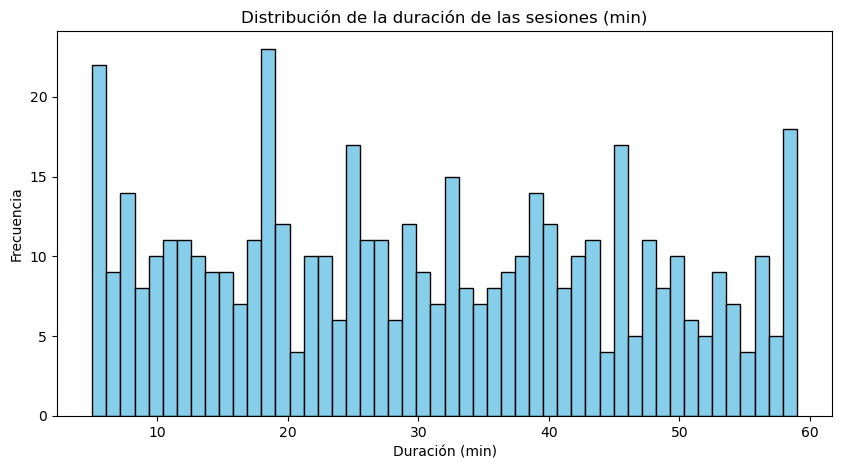

In [42]:
# Distribución de la duración de las sesiones
plt.figure(figsize=(10, 5))
plt.hist(df_visits['session_duration'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la duración de las sesiones (min)')
plt.xlabel('Duración (min)')
plt.ylabel('Frecuencia')
plt.show()

In [43]:
# Calcular la frecuencia de retorno para cada usuario
df_visits_sorted = df_visits.sort_values(by=['Uid', 'Start Ts'])

df_visits_sorted['start_month'] = df_visits_sorted["Start Ts"].dt.month
df_visits_sorted['end_month'] = df_visits_sorted["End Ts"].dt.month

df_visits_sorted.head()

,Uid,Device,Start Ts,End Ts,Source Id,session_duration,date,month,start_month,end_month
491,U001,mobile,2025-01-04 10:00:59,2025-01-04 10:25:59,facebook,25.0,2025-01-04,1,1,1
146,U001,tablet,2025-01-05 15:56:12,2025-01-05 16:13:12,facebook,17.0,2025-01-05,1,1,1
290,U001,mobile,2025-01-09 09:15:20,2025-01-09 09:31:20,google,16.0,2025-01-09,1,1,1
486,U001,mobile,2025-01-13 05:25:08,2025-01-13 05:56:08,linkedin,31.0,2025-01-13,1,1,1
484,U001,tablet,2025-01-24 21:58:54,2025-01-24 22:57:54,linkedin,59.0,2025-01-24,1,1,1


In [44]:
df_visits_sorted.groupby('Uid')['start_month'].shift(1)

491    NaN
146    1.0
290    1.0
486    1.0
484    1.0
      ... 
464    2.0
379    2.0
11     NaN
325    1.0
85     1.0
Name: start_month, Length: 500, dtype: float64

In [45]:
df_visits_sorted['prev_visit'] = df_visits_sorted.groupby('Uid')['start_month'].shift(1)
df_visits_sorted.head()

,Uid,Device,Start Ts,End Ts,Source Id,session_duration,date,month,start_month,end_month,prev_visit
491,U001,mobile,2025-01-04 10:00:59,2025-01-04 10:25:59,facebook,25.0,2025-01-04,1,1,1,NaN
146,U001,tablet,2025-01-05 15:56:12,2025-01-05 16:13:12,facebook,17.0,2025-01-05,1,1,1,1.0
290,U001,mobile,2025-01-09 09:15:20,2025-01-09 09:31:20,google,16.0,2025-01-09,1,1,1,1.0
486,U001,mobile,2025-01-13 05:25:08,2025-01-13 05:56:08,linkedin,31.0,2025-01-13,1,1,1,1.0
484,U001,tablet,2025-01-24 21:58:54,2025-01-24 22:57:54,linkedin,59.0,2025-01-24,1,1,1,1.0


In [46]:

df_visits_sorted['months_since_last'] = (df_visits_sorted['start_month'] - df_visits_sorted['prev_visit'])

display(df_visits_sorted[['Uid', 'Start Ts', 'prev_visit', 'months_since_last']].head(10))

,Uid,Start Ts,prev_visit,months_since_last
491,U001,2025-01-04 10:00:59,NaN,NaN
146,U001,2025-01-05 15:56:12,1.0,0.0
290,U001,2025-01-09 09:15:20,1.0,0.0
486,U001,2025-01-13 05:25:08,1.0,0.0
484,U001,2025-01-24 21:58:54,1.0,0.0
112,U001,2025-02-01 08:46:15,1.0,1.0
274,U001,2025-02-05 06:29:58,2.0,0.0
192,U001,2025-02-12 07:19:45,2.0,0.0
230,U001,2025-02-14 22:55:03,2.0,0.0
20,U002,2025-01-28 02:07:37,NaN,NaN


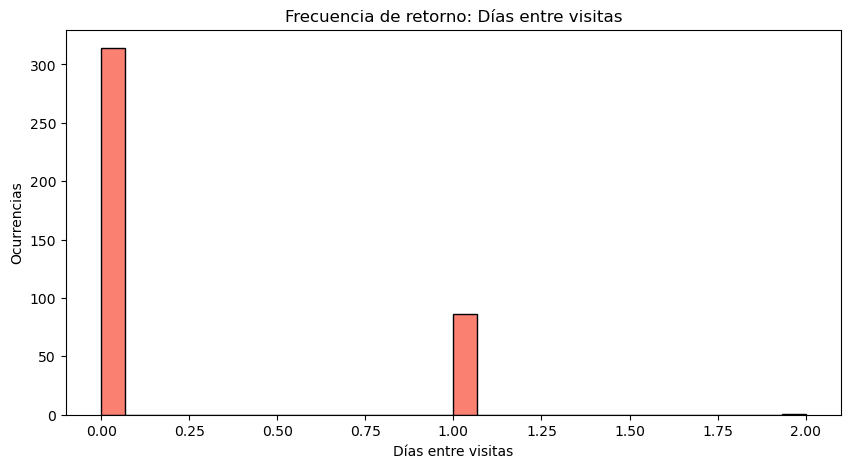

In [47]:
# Histograma de días entre visitas (sin valores nulos)
plt.figure(figsize=(10, 5))
plt.hist(df_visits_sorted['months_since_last'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('Frecuencia de retorno: Días entre visitas')
plt.xlabel('Días entre visitas')
plt.ylabel('Ocurrencias')
plt.show()

### 4.2. Análisis de Ventas

Este apartado se enfoca en:

- **Tiempo hasta la conversión:** Diferencia entre la primera visita y el primer pedido para cada usuario, permitiendo categorizar en cohortes (por ejemplo, Conversion 0d, Conversion 1d, etc.).
- **Cantidad de pedidos y tamaño promedio de compra:** Se agrupan los pedidos por día y se calcula la media del ingreso para evaluar el tamaño de compra.
- **Lifetime Value (LTV):** Suma total de ingresos generados por usuario.

In [48]:
orders.head()

,Uid,Buy Ts,Revenue
0,U088,2025-01-17 07:00:24,34.293185
1,U094,2025-02-17 15:40:05,53.734150
2,U002,2025-02-05 04:47:24,185.277440
3,U063,2025-01-15 22:58:06,156.724834
4,U020,2025-01-11 16:07:31,182.233282


In [49]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Uid      200 non-null    object        
 1   Buy Ts   200 non-null    datetime64[ns]
 2   Revenue  200 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 4.8+ KB


In [50]:
# Extraer la primera visita (registro) de cada usuario
first_visit = df_visits.groupby('Uid')['Start Ts'].min().reset_index().rename(columns={'Start Ts': 'first_visit'})
first_visit.head()

,Uid,first_visit
0,U001,2025-01-04 10:00:59
1,U002,2025-01-28 02:07:37
2,U003,2025-01-19 12:55:42
3,U004,2025-01-03 18:04:42
4,U005,2025-01-04 06:21:51


In [51]:
# Extraer el primer pedido de cada usuario
first_order = orders.groupby('Uid')['Buy Ts'].min().reset_index().rename(columns={'Buy Ts': 'first_order'})
first_order.head()

,Uid,first_order
0,U002,2025-01-31 02:34:06
1,U003,2025-01-25 16:19:39
2,U004,2025-01-03 22:43:26
3,U005,2025-01-07 03:24:45
4,U006,2025-01-30 14:51:25


In [52]:
# Unir ambas tablas para calcular el tiempo hasta conversión
conversion = pd.merge(first_visit, first_order, on='Uid', how='inner')
conversion.head()

,Uid,first_visit,first_order
0,U002,2025-01-28 02:07:37,2025-01-31 02:34:06
1,U003,2025-01-19 12:55:42,2025-01-25 16:19:39
2,U004,2025-01-03 18:04:42,2025-01-03 22:43:26
3,U005,2025-01-04 06:21:51,2025-01-07 03:24:45
4,U006,2025-01-29 07:25:23,2025-01-30 14:51:25


In [53]:
conversion['conversion_days'] = (conversion['first_order'] - conversion['first_visit']).dt.days
conversion.head()

,Uid,first_visit,first_order,conversion_days
0,U002,2025-01-28 02:07:37,2025-01-31 02:34:06,3
1,U003,2025-01-19 12:55:42,2025-01-25 16:19:39,6
2,U004,2025-01-03 18:04:42,2025-01-03 22:43:26,0
3,U005,2025-01-04 06:21:51,2025-01-07 03:24:45,2
4,U006,2025-01-29 07:25:23,2025-01-30 14:51:25,1


In [54]:
print("Tiempo hasta la conversión (días) para algunos usuarios:")
display(conversion[['Uid', 'first_visit', 'first_order', 'conversion_days']].head(10))

Tiempo hasta la conversión (días) para algunos usuarios:


,Uid,first_visit,first_order,conversion_days
0,U002,2025-01-28 02:07:37,2025-01-31 02:34:06,3
1,U003,2025-01-19 12:55:42,2025-01-25 16:19:39,6
2,U004,2025-01-03 18:04:42,2025-01-03 22:43:26,0
3,U005,2025-01-04 06:21:51,2025-01-07 03:24:45,2
4,U006,2025-01-29 07:25:23,2025-01-30 14:51:25,1
5,U008,2025-01-24 17:44:12,2025-01-31 04:23:05,6
6,U009,2025-01-03 08:07:21,2025-01-07 04:20:46,3
7,U011,2025-02-16 14:07:41,2025-02-18 14:44:45,2
8,U012,2025-01-12 00:08:46,2025-01-15 05:12:36,3
9,U013,2025-01-24 21:27:38,2025-01-27 00:34:58,2


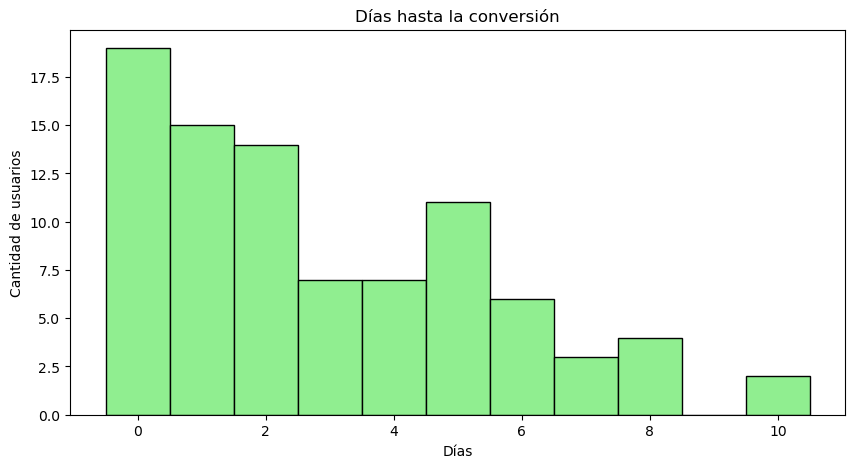

In [55]:
# Histograma de los días hasta la conversión
plt.figure(figsize=(10, 5))
plt.hist(conversion['conversion_days'], bins=range(0, conversion['conversion_days'].max()+2), color='lightgreen', edgecolor='black', align='left')
plt.title('Días hasta la conversión')
plt.xlabel('Días')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [56]:
orders.head()

,Uid,Buy Ts,Revenue
0,U088,2025-01-17 07:00:24,34.293185
1,U094,2025-02-17 15:40:05,53.734150
2,U002,2025-02-05 04:47:24,185.277440
3,U063,2025-01-15 22:58:06,156.724834
4,U020,2025-01-11 16:07:31,182.233282


In [57]:
# Pedidos por día
orders['order_date'] = orders['Buy Ts'].dt.date
orders.head()

,Uid,Buy Ts,Revenue,order_date
0,U088,2025-01-17 07:00:24,34.293185,2025-01-17
1,U094,2025-02-17 15:40:05,53.734150,2025-02-17
2,U002,2025-02-05 04:47:24,185.277440,2025-02-05
3,U063,2025-01-15 22:58:06,156.724834,2025-01-15
4,U020,2025-01-11 16:07:31,182.233282,2025-01-11


In [58]:
orders_per_day = orders.groupby('order_date').size()
orders_per_day.head()

order_date
2025-01-02    4
2025-01-03    3
2025-01-04    3
2025-01-05    2
2025-01-06    6
dtype: int64

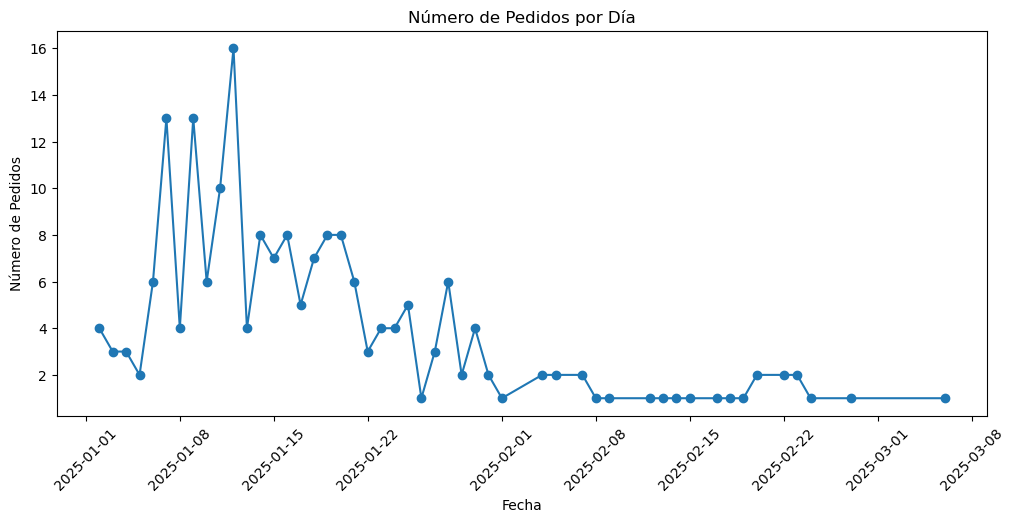

In [59]:
plt.figure(figsize=(12, 5))
orders_per_day.plot(kind='line', marker='o')
plt.title('Número de Pedidos por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.show()

In [60]:
orders.describe()

,Buy Ts,Revenue
count,200,200.000000
mean,2025-01-19 07:19:10.644999936,105.522948
min,2025-01-02 00:47:47,20.281719
25%,2025-01-10 05:10:20,53.953873
50%,2025-01-16 01:39:44.500000,103.695931
75%,2025-01-24 10:58:44,154.595362
max,2025-03-06 09:57:11,199.178753
std,NaN,56.082774


In [61]:
# Tamaño promedio de compra
average_order_value = orders['Revenue'].mean()
print(f"Tamaño promedio de compra: ${average_order_value:.2f}")

Tamaño promedio de compra: $105.52


In [62]:
# Lifetime Value (LTV) por usuario
ltv_per_user = orders.groupby('Uid')['Revenue'].sum()
print("Ejemplo de LTV por usuario:")
display(ltv_per_user.head(20))

Ejemplo de LTV por usuario:


Uid
U002    398.044117
U003    178.758591
U004    329.128027
U005    378.496351
U006     57.315621
U008    101.710433
U009    445.244714
U011    319.863455
U012    307.325218
U013    246.007771
U014    315.288374
U015    501.491435
U016    140.033796
U017    157.367952
U018    107.480089
U019    228.953821
U020    251.943802
U021     49.743569
U022    266.252899
U023    293.310752
Name: Revenue, dtype: float64

### 4.3. Análisis de Marketing

Se analizan los siguientes aspectos:

1. **Gasto total en publicidad:** Tanto global como segmentado por *source_id*.
2. **Costo de adquisición de clientes (CAC):** Gasto dividido entre el número de usuarios convertidos, usando la fuente de adquisición que aparece en la primera visita.
3. **Rentabilidad (ROMI):** Cálculo del retorno de la inversión basado en los ingresos generados por fuente y el gasto asociado.

Además, se generan gráficos para visualizar estas métricas y se segmenta la información por dispositivo.

In [63]:
costs.head(10)

,source_id,dt,costs
0,google,2025-01-29,589.425155
1,facebook,2025-02-02,189.880139
2,google,2025-03-01,719.239999
3,google,2025-01-27,317.699995
4,linkedin,2025-01-25,919.961832
5,twitter,2025-02-25,854.438824
6,facebook,2025-02-24,738.444670
7,linkedin,2025-01-10,953.961360
8,google,2025-02-16,128.279639
9,google,2025-01-23,762.580383


In [64]:
# Gasto total en marketing
total_cost = costs['costs'].sum()
print(f"Gasto total en publicidad: ${total_cost:.2f}")

Gasto total en publicidad: $28375.28


In [65]:
costs['month'] = costs['dt'].dt.month
costs.head()

,source_id,dt,costs,month
0,google,2025-01-29,589.425155,1
1,facebook,2025-02-02,189.880139,2
2,google,2025-03-01,719.239999,3
3,google,2025-01-27,317.699995,1
4,linkedin,2025-01-25,919.961832,1


In [66]:
v1 = costs.groupby(['month', 'source_id']).sum('costs').reset_index()
v1.head()

,month,source_id,costs
0,1,facebook,2197.968200
1,1,google,3179.474317
2,1,linkedin,5001.529939
3,1,twitter,3368.727183
4,2,facebook,4123.873816


In [67]:
# Gasto por fuente
cost_by_source = costs.groupby('source_id')['costs'].sum()
print("Gasto por fuente de adquisición:")
display(cost_by_source)

Gasto por fuente de adquisición:


source_id
facebook    7060.963905
google      8544.823839
linkedin    8546.330654
twitter     4223.166007
Name: costs, dtype: float64

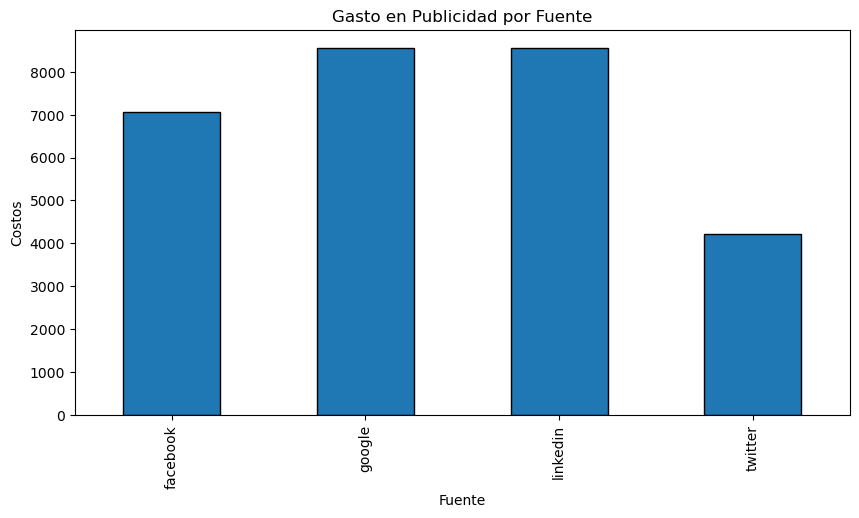

In [68]:
# Graficar gasto por fuente (barras)
plt.figure(figsize=(10,5))
cost_by_source.plot(kind='bar', edgecolor='black')
plt.title('Gasto en Publicidad por Fuente')
plt.xlabel('Fuente')
plt.ylabel('Costos')
plt.show()

In [69]:
df_visits.head()

,Uid,Device,Start Ts,End Ts,Source Id,session_duration,date,month
0,U052,desktop,2025-01-17 09:29:17,2025-01-17 10:14:17,facebook,45.0,2025-01-17,1
1,U093,desktop,2025-02-12 21:25:29,2025-02-12 21:40:29,google,15.0,2025-02-12,2
2,U015,mobile,2025-02-28 11:07:22,2025-02-28 11:15:22,google,8.0,2025-02-28,2
3,U072,desktop,2025-02-13 17:07:45,2025-02-13 17:45:45,google,38.0,2025-02-13,2
4,U061,desktop,2025-02-28 23:00:56,2025-02-28 23:42:56,facebook,42.0,2025-02-28,2


In [70]:
# Suponemos que la fuente de adquisición de cada usuario es la de su primer registro
user_source = df_visits.sort_values(by='Start Ts').groupby('Uid').first().reset_index()[['Uid', 'Source Id']]
user_source.head()

,Uid,Source Id
0,U001,facebook
1,U002,facebook
2,U003,google
3,U004,google
4,U005,facebook


In [71]:
conversion.head()

,Uid,first_visit,first_order,conversion_days
0,U002,2025-01-28 02:07:37,2025-01-31 02:34:06,3
1,U003,2025-01-19 12:55:42,2025-01-25 16:19:39,6
2,U004,2025-01-03 18:04:42,2025-01-03 22:43:26,0
3,U005,2025-01-04 06:21:51,2025-01-07 03:24:45,2
4,U006,2025-01-29 07:25:23,2025-01-30 14:51:25,1


In [72]:
# Unir la información de conversión con la fuente
conversion_with_source = pd.merge(conversion, user_source, on='Uid', how='left')
conversion_with_source.head()

,Uid,first_visit,first_order,conversion_days,Source Id
0,U002,2025-01-28 02:07:37,2025-01-31 02:34:06,3,facebook
1,U003,2025-01-19 12:55:42,2025-01-25 16:19:39,6,google
2,U004,2025-01-03 18:04:42,2025-01-03 22:43:26,0,google
3,U005,2025-01-04 06:21:51,2025-01-07 03:24:45,2,facebook
4,U006,2025-01-29 07:25:23,2025-01-30 14:51:25,1,twitter


In [73]:
# Número de clientes adquiridos por fuente
customers_by_source = conversion_with_source.groupby('Source Id')['Uid'].nunique()
print("Clientes adquiridos por fuente:")
display(customers_by_source)


Clientes adquiridos por fuente:


Source Id
facebook    21
google      25
linkedin    27
twitter     15
Name: Uid, dtype: int64

In [74]:
### Cálculo del Costo de Adquisición de Clientes (CAC)
# Calcular el CAC: gasto de la fuente / número de clientes adquiridos
cac = cost_by_source / customers_by_source
print("Costo de Adquisición de Clientes (CAC) por fuente:")
display(cac)

Costo de Adquisición de Clientes (CAC) por fuente:


source_id
facebook    336.236376
google      341.792954
linkedin    316.530765
twitter     281.544400
dtype: float64

### Cálculo del ROMI (Return on Marketing Investment)

In [75]:
user_source.head()

,Uid,Source Id
0,U001,facebook
1,U002,facebook
2,U003,google
3,U004,google
4,U005,facebook


In [69]:
# Asociar órdenes con la fuente de adquisición (utilizando la fuente del primer registro)
orders_with_source = pd.merge(orders, user_source, on='Uid', how='left')
orders_with_source.head()

,Uid,Buy Ts,Revenue,Source Id
0,U088,2025-01-17 07:00:24,34.293185,facebook
1,U094,2025-02-17 15:40:05,53.734150,linkedin
2,U002,2025-02-05 04:47:24,185.277440,facebook
3,U063,2025-01-15 22:58:06,156.724834,google
4,U020,2025-01-11 16:07:31,182.233282,google


In [42]:
# Ingresos por fuente
revenue_by_source = orders_with_source.groupby('Source Id')['Revenue'].sum()
revenue_by_source.head()


Source Id
facebook    5766.326022
google      6835.879720
linkedin    5811.091661
twitter     2691.292193
Name: Revenue, dtype: float64

In [43]:
# Calcular ROMI: (ingresos - gasto) / gasto
romi = (revenue_by_source - cost_by_source) / cost_by_source
print("ROMI por fuente de adquisición:")
display(romi)

ROMI por fuente de adquisición:


Source Id
facebook   -0.183351
google     -0.199998
linkedin   -0.320048
twitter    -0.362731
dtype: float64

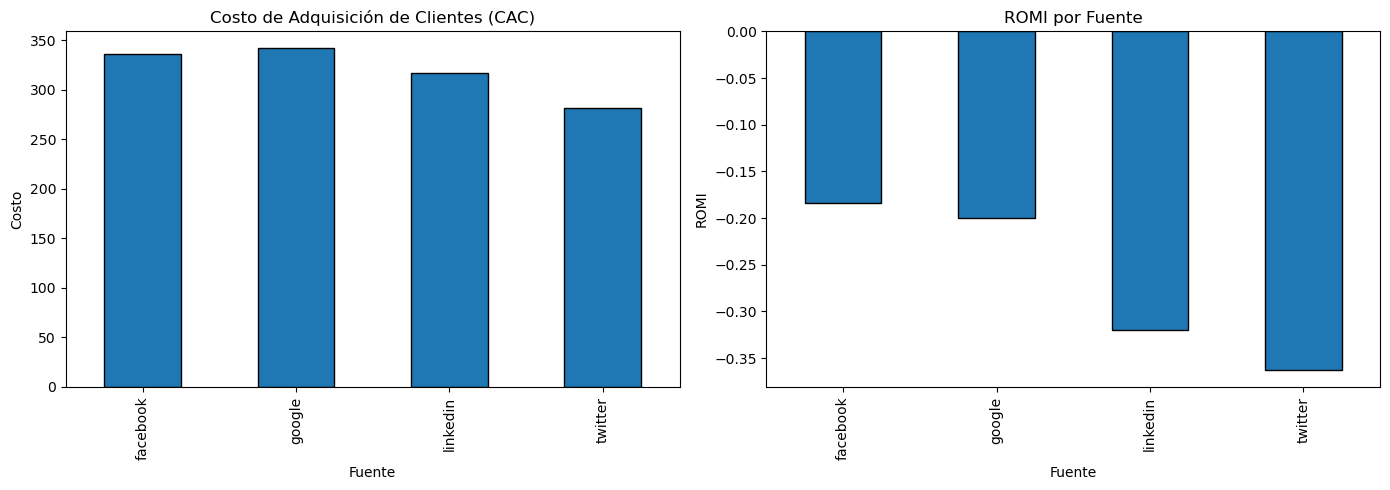

In [44]:
# Graficar CAC y ROMI
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cac.plot(kind='bar', ax=ax[0], edgecolor='black')
ax[0].set_title('Costo de Adquisición de Clientes (CAC)')
ax[0].set_xlabel('Fuente')
ax[0].set_ylabel('Costo')

romi.plot(kind='bar', ax=ax[1], edgecolor='black')
ax[1].set_title('ROMI por Fuente')
ax[1].set_xlabel('Fuente')
ax[1].set_ylabel('ROMI')

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

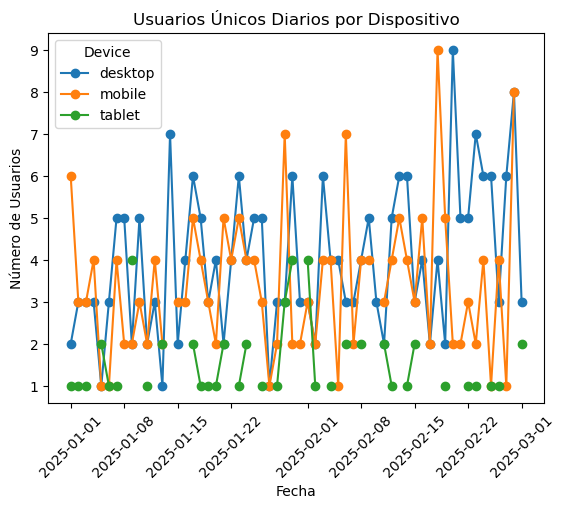

In [45]:
### Análisis adicional: Segmentación por dispositivo

# Número de usuarios únicos diarios por dispositivo
users_by_device = df_visits.groupby([df_visits['Start Ts'].dt.date, 'Device'])['Uid'].nunique().unstack()

plt.figure(figsize=(12, 5))
users_by_device.plot(kind='line', marker='o')
plt.title('Usuarios Únicos Diarios por Dispositivo')
plt.xlabel('Fecha')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)
plt.legend(title='Device')
plt.show()

## 5. Conclusiones y Recomendaciones de Marketing

Tras analizar las métricas, se destacan los siguientes puntos:

- **Tiempo hasta la conversión:** Se observa que un número importante de usuarios realiza la primera compra en 0 o 1 día, lo cual indica que ciertos canales pueden atraer usuarios altamente interesados desde el primer contacto.

- **Costo de Adquisición (CAC):** La comparación del CAC entre las fuentes muestra que algunas permiten adquirir clientes a menor costo. Esto sugiere focalizar la inversión en estos canales.

- **Rentabilidad (ROMI):** Las fuentes con altos ingresos en comparación con el gasto son las más rentables. Las inversiones en canales con ROMI negativo deben ser evaluadas y optimizadas.

- **Segmentación por dispositivo:** Se observan diferencias en el comportamiento de los usuarios según el dispositivo, lo que sugiere adaptar las estrategias de marketing para cada segmento.

### Recomendación Final:

1. **Invertir en fuentes con bajo CAC y alto ROMI:** Esto permitirá optimizar la inversión en publicidad y lograr un mayor retorno.
2. **Impulsar campañas que generen conversiones rápidas:** Dado que una gran parte de los usuarios realiza su primera compra en el mismo día o al día siguiente, es importante enfocarse en este tipo de campañas.
3. **Revisar y ajustar inversiones en canales de bajo rendimiento:** Canalizar esfuerzos y presupuesto hacia aquellos canales que demuestren mejor rendimiento en conversión y rentabilidad.
4. **Adaptar estrategias según el dispositivo:** Los datos indican que el comportamiento varía entre dispositivos, por lo que las campañas pueden beneficiarse al ser personalizadas para cada segmento.

En resumen, recomiendo destinar una mayor inversión en los canales que, en base a las métricas evaluadas (tiempo hasta la conversión, CAC y ROMI), permiten conseguir conversiones rápidas y rentables. Esto favorecerá el escalado de la inversión publicitaria y optimizará el retorno de la inversión en marketing.